# 🌾 AgriSmart — NB2: Patch Extraction & Augmentation

**Objectif :** Découper l'image satellite Béja (2500×2000) en patches 128×128
et générer les pseudo-labels issus du NB1 (NDVI + K-Means).

**Pourquoi ce notebook ?**
- U-Net exige des entrées de taille fixe → on découpe en patches
- Un stride de 64 (50% overlap) améliore la précision aux bords des champs
- L'augmentation (rotation, flip, bruit) multiplie ×8 les exemples d'entraînement
  et réduit l'overfitting sur nos pseudo-labels imparfaits

**Hardware :** CPU uniquement — 32GB RAM largement suffisant

---
## 📦 Part 1 : Setup

In [13]:
!pip install rasterio numpy scikit-learn matplotlib -q
print('✅ Packages OK')

✅ Packages OK


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gc, warnings
warnings.filterwarnings('ignore')

# ─── CHEMINS (adapter si besoin) ───────────────────────────────────────────
TIFF_PATH   = '/content/drive/MyDrive/GEE_Exports/S2_Beja_2025.tif'
TEMP_DIR    = Path('/content/drive/MyDrive/temp_indices_agrismart')   # créé par NB1
OUTPUT_DIR  = Path('/content/drive/MyDrive/patches') # Modification ici pour sauvegarder dans Google Drive
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'images').mkdir(exist_ok=True)
(OUTPUT_DIR / 'labels').mkdir(exist_ok=True)

# ─── PARAMÈTRES ────────────────────────────────────────────────────────────
PATCH_SIZE   = 128   # taille des patches (pixels)
STRIDE       = 64    # pas du sliding window (50% overlap)
MIN_VALID    = 0.05  # rejeter patches avec >95% pixels nodata (modifié de 0.30 à 0.05)
N_BANDS      = 9     # Blue, Green, Red, NIR + NDVI, EVI, SAVI, NDMI, NDWI

def clear_mem():
    gc.collect()

print('✅ Setup OK')

✅ Setup OK


---
## 📂 Part 2 : Chargement des bandes + indices depuis NB1

In [16]:
import rasterio
from rasterio.enums import Resampling
from pathlib import Path
import numpy as np # Ensure numpy is imported for np.float32, np.uint8, np.unique

TEMP_DIR = Path('/content/drive/MyDrive/temp_indices_agrismart') # Fix: Correct path to temp_indices_agrismart

DOWNSAMPLE = 2

print('📥 Chargement des bandes spectrales...')
with rasterio.open(TIFF_PATH) as src:
    data = src.read(
        out_shape=(src.count, src.height // DOWNSAMPLE, src.width // DOWNSAMPLE),
        resampling=Resampling.average
    ).transpose(1, 2, 0)

blue = data[:,:,0].astype(np.float32) / 10000
green= data[:,:,1].astype(np.float32) / 10000
red  = data[:,:,2].astype(np.float32) / 10000
nir  = data[:,:,3].astype(np.float32) / 10000
del data; clear_mem()

H, W = blue.shape
print(f'✅ Bandes chargées : {W}×{H} pixels')

# Chargement des indices sauvegardés par NB1
def load(name):
    return np.load(TEMP_DIR / f'{name}.npy').astype(np.float32)

ndvi = load('ndvi')
evi  = load('evi')
savi = load('savi')
ndmi = load('ndmi')
ndwi = load('ndwi')

# Labels pseudo (NDVI classification produite par NB1)
labels = load('ndvi_classes').astype(np.uint8)

print('✅ Indices et labels chargés')
print(f'   Classes uniques : {np.unique(labels)}')

📥 Chargement des bandes spectrales...
✅ Bandes chargées : 5365×4619 pixels
✅ Indices et labels chargés
   Classes uniques : [0 1 2 3 4 5]


---
## 🔧 Part 3 : Construction du stack de features (9 bandes)

In [17]:
# Stack : (H, W, 9)
print('📐 Construction du stack features...')
feature_stack = np.dstack([blue, green, red, nir, ndvi, evi, savi, ndmi, ndwi])

# ✅ FIX : masque nodata AVANT normalisation (pixels sans données = 0 sur toutes les bandes)
nodata_mask = (blue == 0) & (red == 0) & (nir == 0)
print(f'   Pixels nodata : {nodata_mask.sum():,} ({nodata_mask.mean()*100:.1f}%)')

del blue, green, red, nir, ndvi, evi, savi, ndmi, ndwi
clear_mem()

print('📐 Normalisation Z-score...')
for b in range(feature_stack.shape[2]):
    band = feature_stack[:,:,b]
    valid = ~nodata_mask  # ✅ utiliser le vrai masque nodata
    if valid.sum() > 0:
        mu = band[valid].mean()
        sigma = band[valid].std() + 1e-8
        feature_stack[:,:,b] = (band - mu) / sigma
    feature_stack[:,:,b] = np.clip(feature_stack[:,:,b], -3, 3)

feature_stack = np.nan_to_num(feature_stack, nan=0.0, posinf=3.0, neginf=-3.0)
print(f'✅ NaN résiduels : {np.isnan(feature_stack).sum()} ← doit afficher 0')
print(f'✅ Stack : shape={feature_stack.shape}, dtype={feature_stack.dtype}')
print(f'   RAM : {feature_stack.nbytes/1e9:.2f} GB')

📐 Construction du stack features...
   Pixels nodata : 0 (0.0%)
📐 Normalisation Z-score...
✅ NaN résiduels : 0 ← doit afficher 0
✅ Stack : shape=(4619, 5365, 9), dtype=float32
   RAM : 0.89 GB


---
## ✂️ Part 4 : Extraction des patches (sliding window)

**Stratégie :** fenêtre glissante 128×128, stride 64 (50% overlap).  
Les patches avec plus de 30% de pixels nodata (=0) sont rejetés  
(zones nuageuses ou hors AOI).

In [18]:
patch_count = 0
rejected    = 0
patch_ids   = []  # pour retrouver la position de chaque patch

print(f'✂️ Extraction patches {PATCH_SIZE}×{PATCH_SIZE}, stride={STRIDE}...')

for row in range(0, H - PATCH_SIZE + 1, STRIDE):
    for col in range(0, W - PATCH_SIZE + 1, STRIDE):
        img_patch = feature_stack[row:row+PATCH_SIZE, col:col+PATCH_SIZE, :]  # (128,128,9)
        lbl_patch = labels[row:row+PATCH_SIZE, col:col+PATCH_SIZE]            # (128,128)

        # Critère de validité : proportion de pixels non-nuls
# ✅ APRÈS
        nodata_patch = nodata_mask[row:row+PATCH_SIZE, col:col+PATCH_SIZE]
        valid_ratio = 1.0 - np.mean(nodata_patch)
        if valid_ratio < MIN_VALID:
            rejected += 1
            continuevb v

        # Sauvegarde
        np.save(OUTPUT_DIR / 'images' / f'patch_{patch_count:05d}.npy', img_patch.astype(np.float16))
        np.save(OUTPUT_DIR / 'labels' / f'patch_{patch_count:05d}.npy', lbl_patch)
        patch_ids.append((patch_count, row, col))
        patch_count += 1

        if patch_count % 500 == 0:
            print(f'   {patch_count} patches extraits...')

np.save(OUTPUT_DIR / 'patch_positions.npy', np.array(patch_ids))

print(f'\n✅ Extraction terminée')
print(f'   Patches valides  : {patch_count:,}')
print(f'   Patches rejetés  : {rejected:,}')
print(f'   Taux acceptation : {100*patch_count/(patch_count+rejected):.1f}%')

✂️ Extraction patches 128×128, stride=64...
   500 patches extraits...
   1000 patches extraits...
   1500 patches extraits...
   2000 patches extraits...
   2500 patches extraits...
   3000 patches extraits...
   3500 patches extraits...
   4000 patches extraits...
   4500 patches extraits...
   5000 patches extraits...
   5500 patches extraits...

✅ Extraction terminée
   Patches valides  : 5,822
   Patches rejetés  : 0
   Taux acceptation : 100.0%


---
## 🔀 Part 5 : Data Augmentation

**Pourquoi ?** Nos pseudo-labels (K-Means+NDVI) sont bruités.  
L'augmentation expose le modèle à plus de variété et réduit l'overfitting.  
On applique : rotations 90°/180°/270°, flip H, flip V, bruit gaussien.

**Résultat :** ×7 plus de patches d'entraînement (uniquement sur le train set).

In [19]:
def augment_pair(img, lbl):
    """
    Génère 7 versions augmentées d'un patch (img: H,W,C / lbl: H,W).
    Retourne liste de (img, lbl).
    """
    augmented = []

    # Rotations 90°, 180°, 270°
    for k in [1, 2, 3]:
        augmented.append((
            np.rot90(img, k=k, axes=(0,1)),
            np.rot90(lbl, k=k)
        ))

    # Flip horizontal
    augmented.append((np.flip(img, axis=1), np.flip(lbl, axis=1)))

    # Flip vertical
    augmented.append((np.flip(img, axis=0), np.flip(lbl, axis=0)))

    # Flip diagonal
    augmented.append((np.transpose(img, (1,0,2)), lbl.T))

    # Bruit gaussien léger (sigma = 0.05 sur données normalisées)
    noise = img + np.random.normal(0, 0.05, img.shape).astype(np.float16)
    noise = np.clip(noise, -3, 3)
    augmented.append((noise, lbl))

    return augmented

print('✅ Fonction augmentation définie (7 transformations par patch)')

✅ Fonction augmentation définie (7 transformations par patch)


---
## 📊 Part 6 : Split train/val/test + sauvegarde des splits

In [20]:
from sklearn.model_selection import train_test_split

all_ids = list(range(patch_count))
np.random.seed(42)

# Split 70 / 10 / 20 (train / val / test) — rapport section 7.2
train_ids, temp_ids = train_test_split(all_ids, test_size=0.30, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids, test_size=0.67, random_state=42)

print('📊 Distribution des splits :')
print(f'   Train : {len(train_ids):,} patches  (avant augmentation)')
print(f'   Val   : {len(val_ids):,} patches')
print(f'   Test  : {len(test_ids):,} patches')
print(f'   Train augmenté : ~{len(train_ids)*8:,} patches (×8)')

np.save(OUTPUT_DIR / 'split_train.npy', np.array(train_ids))
np.save(OUTPUT_DIR / 'split_val.npy',   np.array(val_ids))
np.save(OUTPUT_DIR / 'split_test.npy',  np.array(test_ids))

print('\n✅ Splits sauvegardés')

📊 Distribution des splits :
   Train : 4,075 patches  (avant augmentation)
   Val   : 576 patches
   Test  : 1,171 patches
   Train augmenté : ~32,600 patches (×8)

✅ Splits sauvegardés


---
## 🔍 Part 7 : Vérification visuelle des patches

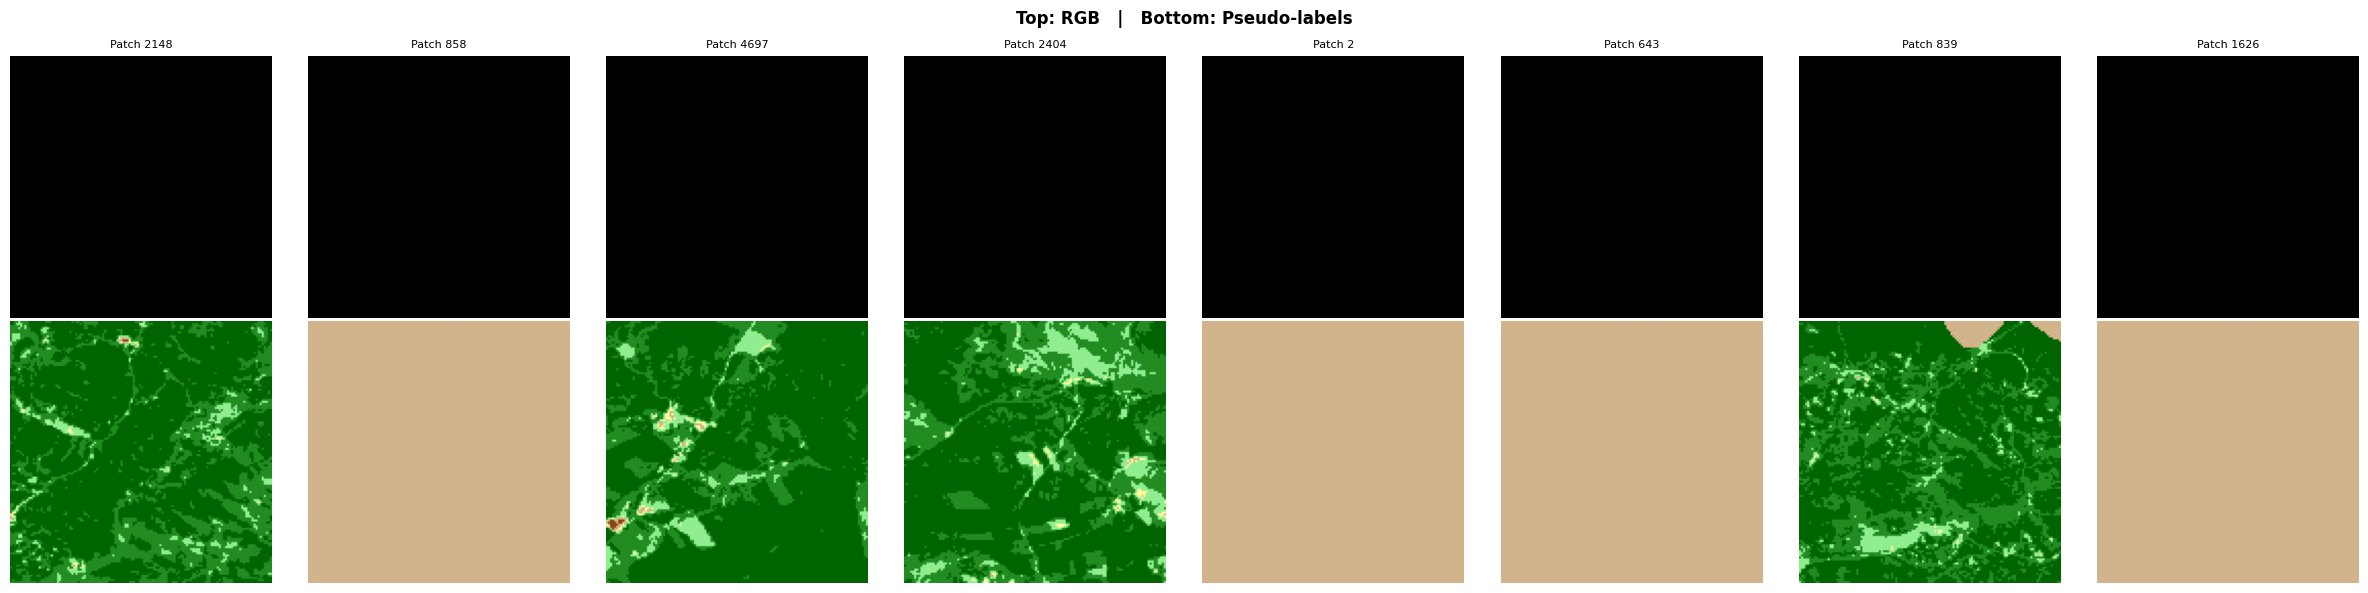

Classes : Eau/Roche, Sol nu, Vég. sparse, Vég. modérée, Vég. dense, Très dense


In [21]:
# Visualiser 8 patches aléatoires avec leurs labels
sample_ids = np.random.choice(train_ids, size=8, replace=False)

class_names  = ['Eau/Roche', 'Sol nu', 'Vég. sparse', 'Vég. modérée', 'Vég. dense', 'Très dense']
class_colors = ['#8B4513', '#D2B48C', '#FFFF99', '#90EE90', '#228B22', '#006400']

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

cmap = ListedColormap(class_colors)
fig, axes = plt.subplots(2, 8, figsize=(24, 6))

for i, pid in enumerate(sample_ids):
    img = np.load(OUTPUT_DIR / 'images' / f'patch_{pid:05d}.npy').astype(np.float32)
    lbl = np.load(OUTPUT_DIR / 'labels' / f'patch_{pid:05d}.npy')

    # Reconstruire RGB depuis les 3 premières bandes (B,G,R)
    rgb = img[:,:,[2,1,0]]  # R,G,B
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    axes[0, i].imshow(rgb)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Patch {pid}', fontsize=8)

    axes[1, i].imshow(lbl, cmap=cmap, vmin=0, vmax=5)
    axes[1, i].axis('off')

plt.suptitle('Top: RGB   |   Bottom: Pseudo-labels', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('NB2_patch_samples.png', dpi=120, bbox_inches='tight')
plt.show()

patches_legend = [mpatches.Patch(color=class_colors[i], label=class_names[i]) for i in range(6)]
print('Classes :', ', '.join(class_names))

---
## 📈 Part 8 : Distribution des classes dans les patches

On vérifie l'équilibre des classes pour le paramétrage du loss (weighted cross-entropy)

📊 Distribution des classes (échantillon 1000 patches) :
Eau/Roche          |                                                    0.5%  poids=4.50
Sol nu             | ██████████████████████████                         52.6%  poids=0.04
Vég. sparse        | █                                                  2.5%  poids=0.94
Vég. modérée       | ████                                               9.4%  poids=0.25
Vég. dense         | ████████                                           17.8%  poids=0.13
Très dense         | ████████                                           17.2%  poids=0.14

✅ Poids sauvegardés → utilisés dans NB3 pour le loss


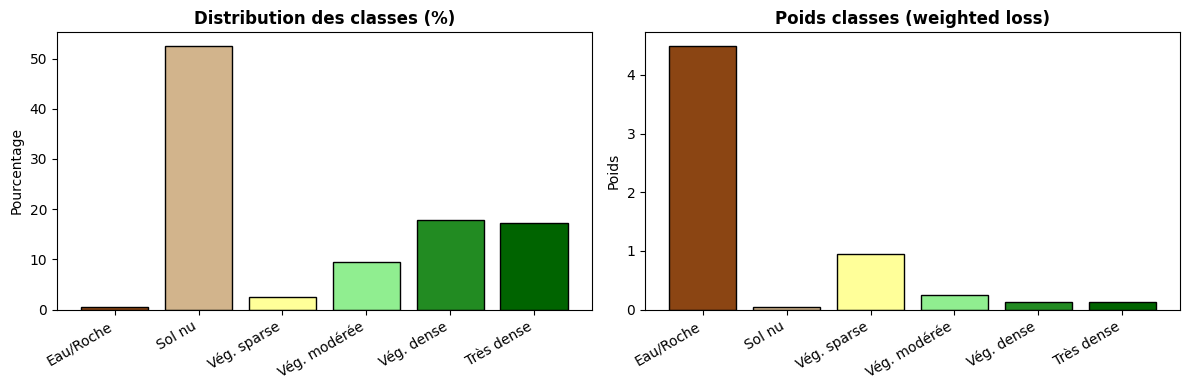

In [22]:
# Compter la distribution sur un échantillon de 1000 patches train
sample = np.random.choice(train_ids, size=min(1000, len(train_ids)), replace=False)
class_counts = np.zeros(6, dtype=np.int64)

for pid in sample:
    lbl = np.load(OUTPUT_DIR / 'labels' / f'patch_{pid:05d}.npy')
    for c in range(6):
        class_counts[c] += np.sum(lbl == c)

total = class_counts.sum()
class_freq = class_counts / total

# Poids inversement proportionnels à la fréquence (pour le loss)
# Justification : dominant class (Moderate Veg) = 31.2% selon rapport
class_weights = 1.0 / (class_freq + 1e-6)
class_weights = class_weights / class_weights.sum() * 6  # normaliser

print('📊 Distribution des classes (échantillon 1000 patches) :')
print('=' * 60)
for i in range(6):
    bar = '█' * int(class_freq[i] * 50)
    print(f'{class_names[i]:18} | {bar:<50} {class_freq[i]*100:.1f}%  poids={class_weights[i]:.2f}')

np.save(OUTPUT_DIR / 'class_weights.npy', class_weights)
print('\n✅ Poids sauvegardés → utilisés dans NB3 pour le loss')

# Graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(class_names, class_freq * 100, color=class_colors, edgecolor='k')
ax1.set_title('Distribution des classes (%)', fontweight='bold')
ax1.set_xticklabels(class_names, rotation=30, ha='right')
ax1.set_ylabel('Pourcentage')

ax2.bar(class_names, class_weights, color=class_colors, edgecolor='k')
ax2.set_title('Poids classes (weighted loss)', fontweight='bold')
ax2.set_xticklabels(class_names, rotation=30, ha='right')
ax2.set_ylabel('Poids')

plt.tight_layout()
plt.savefig('NB2_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ✅ Part 9 : Résumé

Ce notebook a produit dans `patches/` :
- `images/patch_XXXXX.npy` — tenseurs (128, 128, 9) float16
- `labels/patch_XXXXX.npy` — masques (128, 128) uint8
- `split_train/val/test.npy` — indices des splits
- `class_weights.npy` — poids pour le weighted cross-entropy loss
- `patch_positions.npy` — position (row, col) de chaque patch dans l'image originale

**→ Prêt pour NB3 : U-Net Training**

In [23]:
print('=== RÉSUMÉ NB2 ===')
print(f'Total patches : {patch_count:,}')
print(f'Train         : {len(train_ids):,} (×8 augmenté = ~{len(train_ids)*8:,})')
print(f'Val           : {len(val_ids):,}')
print(f'Test          : {len(test_ids):,}')
print(f'Shape patches : (128, 128, 9) float16')
import os
total_mb = sum(os.path.getsize(f) for f in OUTPUT_DIR.rglob('*.npy')) / 1e6
print(f'Taille disque : {total_mb:.0f} MB')
print('\n✅ NB2 terminé → lancer NB3_unet_training.ipynb')

=== RÉSUMÉ NB2 ===
Total patches : 5,822
Train         : 4,075 (×8 augmenté = ~32,600)
Val           : 576
Test          : 1,171
Shape patches : (128, 128, 9) float16
Taille disque : 1814 MB

✅ NB2 terminé → lancer NB3_unet_training.ipynb


### Comment importer `class_weights.npy` dans le notebook NB3

Pour charger les poids des classes enregistrés, vous devez d'abord monter votre Google Drive, puis utiliser `numpy.load` en spécifiant le chemin complet du fichier.

In [24]:
import numpy as np
from google.colab import drive
from pathlib import Path

# Montez Google Drive si ce n'est pas déjà fait dans NB3
drive.mount('/content/drive')

# Définissez le chemin vers le dossier où les patches ont été sauvegardés
OUTPUT_DIR = Path('/content/drive/MyDrive/patches')

# Chargez les poids des classes
class_weights = np.load(OUTPUT_DIR / 'class_weights.npy')

print('Poids des classes importés :')
print(class_weights)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Poids des classes importés :
[4.49983175 0.04448453 0.93985266 0.24826969 0.13146655 0.13609481]
